# Subspace analysis

In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import scipy

from sklearn.linear_model import LinearRegression

import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [ ]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -10, rel_end= 100)

In [67]:
from_area = 'MOp_rates'
to_area = 'CP_rates'

# Get regressor
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), from_area, to_area)

# Get subspace projector
comm_subspace_mop_cp = subspaces.get_output_potent_projector(comm_lr)

# Variances
comm_variances_mop_cp = subspaces.variance_in_subspace_df(perturb_td, from_area, comm_subspace_mop_cp)

In [66]:
from_area = 'CP_rates'
to_area = 'MOp_rates'

# Get regressor
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), from_area, to_area)

# Get subspace projector
comm_subspace_cp_mop = subspaces.get_output_potent_projector(comm_lr)

# Variances
comm_variances_cp_mop= subspaces.variance_in_subspace_df(perturb_td, from_area, comm_subspace_cp_mop)

In [69]:
projected_mop_cp = np.array([arr @ comm_subspace_mop_cp for arr in perturb_td.MOp_rates.values])
projected_cp_mop = np.array([arr @ comm_subspace_cp_mop for arr in perturb_td.CP_rates.values])

In [75]:
targets = df.values_Sol_direction.values.tolist()

In [77]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB


score_mop_cp = cross_val_score(
    GaussianNB(), projected_mop_cp.reshape(-1, projected_mop_cp.shape[1]*projected_mop_cp.shape[2]), 
    targets, scoring="accuracy", cv=5).mean()

score_cp_mop = cross_val_score(
    GaussianNB(), projected_cp_mop.reshape(-1, projected_cp_mop.shape[1]*projected_cp_mop.shape[2]), 
    targets, scoring="accuracy", cv=5).mean()

print(score_mop_cp, score_cp_mop)

0.3363636363636363 0.22211668928086842


In [105]:
output_null_subspace.shape

(178, 0)

In [113]:
areas = ['MOp', 'CP', 'SSp', 'VAL']
data = []
for from_area in areas[:1]:
    data_ = []
    for to_area in areas[1:]:
        print(from_area, to_area)
        comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', f'{to_area}_rates')
        comm_subspace = subspaces.get_output_potent_projector(comm_lr)
        output_null_subspace = subspaces.get_output_null_projector(comm_lr)

        projected_arr = np.array([arr @ output_null_subspace for arr in perturb_td[f'{from_area}_rates'].values])
        cv_score = cross_val_score(
                GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
                targets, scoring="accuracy", cv=5
            ).mean()
        data_.append(cv_score)
        print(f'Comm. subspace {from_area} -> {to_area} score: {cv_score}')
    data_ = np.array(data_)
    data.append(data_)
data = np.array(data)

MOp CP
Comm. subspace MOp -> CP score: 0.17706919945725916
MOp SSp
Comm. subspace MOp -> SSp score: 0.2853459972862958
MOp VAL
Comm. subspace MOp -> VAL score: 0.26146540027137044


<Axes: >

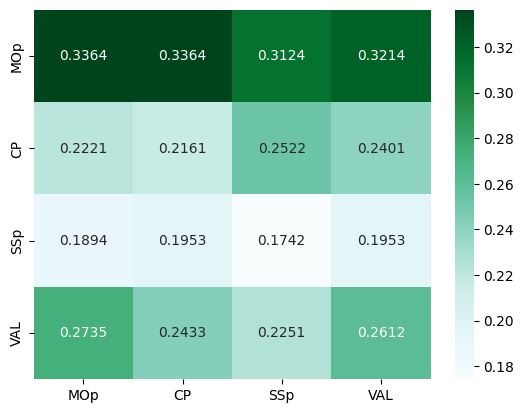

In [93]:
import seaborn as sns
sns.heatmap(
    data,
    xticklabels=areas,
    yticklabels=areas,
    # center=0,
    # vmin=0,
    # vmax=1,
    cmap= 'BuGn',#'BrBG',
    annot=True,
    fmt=".4f",
    # cbar_kws={"label": "Δ Lag (ms)"}
)

In [98]:
df.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
       'al

In [ ]:
from tools.dimensionality.cca import _roll_array


areas = ['MOp', 'CP', 'SSp', 'VAL']
data_delayed = []

shift_dict = {
    'MOp':{
        'MOp': 0,
        'SSp': 0,
        'CP': -1,
        'VAL': -3
    },
    'SSp':{
        'MOp': 1,
        'SSp': 0,
        'CP': 0,
        'VAL': -2
    },
    'CP':{
        'MOp': 2,
        'SSp': 1,
        'CP': 0,
        'VAL': -2
    },
    'VAL':{
        'MOp': 4,
        'SSp': 2,
        'CP': 0,
        'VAL': 0
    },

}

for from_area in areas:
    data_ = []
    for to_area in areas:
        comm_lr = LinearRegression()
        X = pyal.concat_trials(df, f'{from_area}_rates')
        Y = pyal.concat_trials(df, f'{to_area}_rates')
        Y_delayed = _roll_array(Y, shift=shift_dict[from_area][to_area])
        print(shift_dict[from_area][to_area])

        comm_lr.fit(X, Y_delayed)
        comm_subspace = subspaces.get_output_potent_projector(comm_lr)
        projected_arr = np.array([arr @ comm_subspace for arr in perturb_td[f'{from_area}_rates'].values])
        cv_score = cross_val_score(
                GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
                targets, scoring="accuracy", cv=5
            ).mean()
        data_.append(cv_score)
        # print(f'Comm. subspace {from_area} -> {to_area} score: {cv_score}')
    data_ = np.array(data_)
    data_delayed.append(data_)
data_delayed = np.array(data_delayed)

<Axes: >

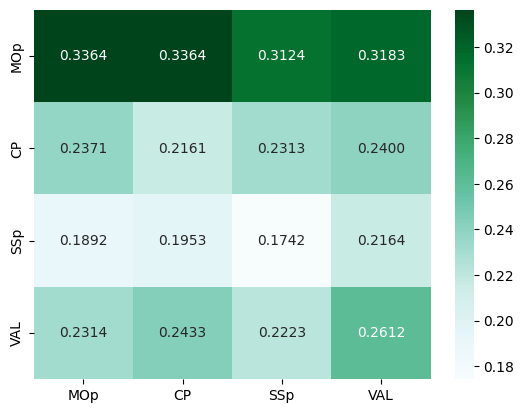

In [97]:
import seaborn as sns
sns.heatmap(
    data_delayed,
    xticklabels=areas,
    yticklabels=areas,
    # center=0,
    # vmin=0,
    # vmax=1,
    cmap= 'BuGn',#'BrBG',
    annot=True,
    fmt=".4f",
    # cbar_kws={"label": "Δ Lag (ms)"}
)

In [117]:
keypoint = 'left_ankle'
for from_area in areas:
    comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', keypoint)
    comm_subspace = subspaces.get_output_potent_projector(comm_lr)
    output_null_subspace = subspaces.get_output_null_projector(comm_lr)
    projected_arr = np.array([arr @ output_null_subspace for arr in perturb_td[f'{from_area}_rates'].values])
    cv_score = cross_val_score(
            GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
            targets, scoring="accuracy", cv=5
        ).mean()
    print(f'Comm. subspace {from_area} -> {keypoint} score: {cv_score}')
    

Comm. subspace MOp -> left_ankle score: 0.24604251469923116
Comm. subspace CP -> left_ankle score: 0.20719131614654004
Comm. subspace SSp -> left_ankle score: 0.20438715513342376
Comm. subspace VAL -> left_ankle score: 0.20741745816372684


In [116]:
keypoint = 'right_ankle'
for from_area in areas:
    comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', keypoint)
    comm_subspace = subspaces.get_output_potent_projector(comm_lr)
    output_null_subspace = subspaces.get_output_null_projector(comm_lr)
    projected_arr = np.array([arr @ comm_subspace for arr in perturb_td[f'{from_area}_rates'].values])
    cv_score = cross_val_score(
            GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
            targets, scoring="accuracy", cv=5
        ).mean()
    print(f'Comm. subspace {from_area} -> {keypoint} score: {cv_score}')
    

Comm. subspace MOp -> right_ankle score: 0.1350067842605156
Comm. subspace CP -> right_ankle score: 0.1290818634102216
Comm. subspace SSp -> right_ankle score: 0.11705110809588422
Comm. subspace VAL -> right_ankle score: 0.13211216644052465


In [141]:
import tools.dataTools as dt
all_kinematics = ['left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip']

df = dt.add_bhv(df, all_kinematics)
scores_comm_subspace = []
for from_area in areas:
    comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', 'bhv')
    comm_subspace = subspaces.get_output_potent_projector(comm_lr)
    output_null_subspace = subspaces.get_output_null_projector(comm_lr)
    projected_arr = np.array([arr @ comm_subspace for arr in perturb_td[f'{from_area}_rates'].values])
    cv_score = cross_val_score(
            GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
            targets, scoring="accuracy", cv=5
        )
    scores_comm_subspace.append(cv_score)
    print(f'Comm. subspace {from_area} -> {keypoint} score: {cv_score.mean()}')
scores_comm_subspace = np.array(scores_comm_subspace)

Comm. subspace MOp -> left_ankle score: 0.32392582541836273
Comm. subspace CP -> left_ankle score: 0.2521935775667119
Comm. subspace SSp -> left_ankle score: 0.17431026684758028
Comm. subspace VAL -> left_ankle score: 0.18331071913161465


In [142]:
import tools.dataTools as dt
all_kinematics = ['left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip']


df = dt.add_bhv(df, all_kinematics)
scores_null_space = []
for from_area in areas:
    comm_lr = pyal.fit_regressor_model(df, LinearRegression(), f'{from_area}_rates', 'bhv')
    comm_subspace = subspaces.get_output_potent_projector(comm_lr)
    output_null_subspace = subspaces.get_output_null_projector(comm_lr)
    projected_arr = np.array([arr @ output_null_subspace for arr in perturb_td[f'{from_area}_rates'].values])
    cv_score = cross_val_score(
            GaussianNB(), projected_arr.reshape(-1, projected_arr.shape[1]*projected_arr.shape[2]), 
            targets, scoring="accuracy", cv=5
        )
    scores_null_space.append(cv_score)
    print(f'Comm. subspace {from_area} -> {keypoint} score: {cv_score.mean()}')
scores_null_space = np.array(scores_null_space)

Comm. subspace MOp -> left_ankle score: 0.2975576662143826
Comm. subspace CP -> left_ankle score: 0.2010854816824966
Comm. subspace SSp -> left_ankle score: 0.15015829941203077
Comm. subspace VAL -> left_ankle score: 0.22225237449118046


In [143]:
scores_comm_subspace.shape

(4, 5)

Text(0.5, 1.0, 'Decoding sol direction from perturb. window. Neurons -> kinematics')

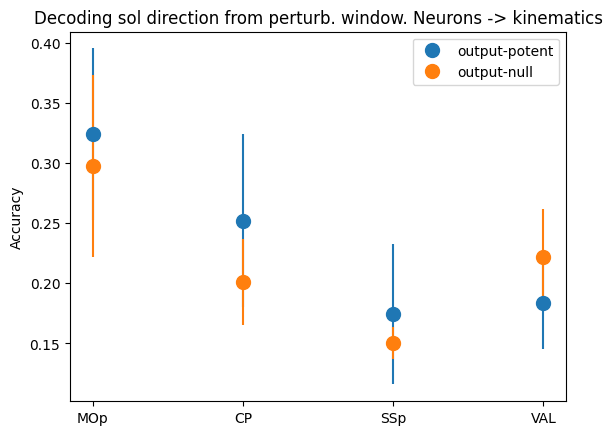

In [150]:
fig, ax = plt.subplots()
ax.errorbar(areas, np.mean(scores_comm_subspace, axis=1), yerr=np.std(scores_comm_subspace, axis=1), fmt='o', markersize=10, label='output-potent')
ax.errorbar(areas, np.mean(scores_null_space, axis=1), yerr=np.std(scores_null_space, axis=1), fmt='o', markersize=10, label='output-null')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_title('Decoding sol direction from perturb. window. Neurons -> kinematics')

### Play around with latencies

In [135]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [136]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)

In [137]:
targets = df.values_Sol_direction.values.tolist()

In [ ]:
from_area = 'SSp_rates'
to_area = 'MOp_rates'
bhv = 'bhv'

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), from_area, to_area)
comm_subspace_ssp_mop = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), to_area, from_area)
comm_subspace_mop_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'bhv')
comm_subspace_mop_bhv = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'CP_rates')
comm_subspace_mop_cp = subspaces.get_output_potent_projector(comm_lr)
comm_null_subspace_mop_cp = subspaces.get_output_null_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'VAL_rates')
comm_subspace_mop_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'CP_rates', 'VAL_rates')
comm_subspace_cp_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'MOp_rates')
comm_subspace_val_mop = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'SSp_rates', 'VAL_rates')
comm_subspace_ssp_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'SSp_rates')
comm_subspace_val_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'SSp_rates', 'CP_rates')
comm_subspace_ssp_cp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'bhv', 'SSp_rates')
comm_subspace_bhv_ssp = subspaces.get_output_potent_projector(comm_lr)

In [140]:
projected_ssp_mop = np.array([arr @ comm_subspace_ssp_mop for arr in perturb_td.SSp_rates.values])
projected_mop_ssp = np.array([arr @ comm_subspace_mop_ssp for arr in perturb_td.MOp_rates.values])
projected_mop_bhv = np.array([arr @ comm_subspace_mop_bhv for arr in perturb_td.MOp_rates.values])
projected_mop_cp = np.array([arr @ comm_subspace_mop_cp for arr in perturb_td.MOp_rates.values])
projected_mop_val = np.array([arr @ comm_subspace_mop_val for arr in perturb_td.MOp_rates.values])
projected_cp_val = np.array([arr @ comm_subspace_cp_val for arr in perturb_td.CP_rates.values])
projected_val_mop = np.array([arr @ comm_subspace_val_mop for arr in perturb_td.VAL_rates.values])
projected_val_ssp = np.array([arr @ comm_subspace_val_ssp for arr in perturb_td.VAL_rates.values])
projected_ssp_val = np.array([arr @ comm_subspace_ssp_val for arr in perturb_td.SSp_rates.values])
projected_ssp_cp = np.array([arr @ comm_subspace_ssp_cp for arr in perturb_td.SSp_rates.values])
projected_bhv_ssp = np.array([arr @ comm_subspace_bhv_ssp for arr in perturb_td.bhv.values])

bhv = np.stack(perturb_td.bhv.values)
mop = np.stack(perturb_td.MOp_rates.values)
ssp = np.stack(perturb_td.SSp_rates.values)
cp = np.stack(perturb_td.CP_rates.values)
val = np.stack(perturb_td.VAL_rates.values)





In [141]:
k=5
scores_ssp_mop, times = decode.moving_window_decoding(
    projected_ssp_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_ssp, times = decode.moving_window_decoding(
    projected_mop_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_bhv, times = decode.moving_window_decoding(
    projected_mop_bhv,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_bhv, times = decode.moving_window_decoding(
    bhv,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_cp, times = decode.moving_window_decoding(
    projected_mop_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_val, times = decode.moving_window_decoding(
    projected_mop_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_cp_val, times = decode.moving_window_decoding(
    projected_cp_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_mop, times = decode.moving_window_decoding(
    projected_val_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_ssp_val, times = decode.moving_window_decoding(
    projected_ssp_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_ssp, times = decode.moving_window_decoding(
    projected_val_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_ssp_cp, times = decode.moving_window_decoding(
    projected_ssp_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_bhv_ssp, times = decode.moving_window_decoding(
    projected_bhv_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

In [142]:
scores_ssp, times = decode.moving_window_decoding(
    ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)
scores_mop, times = decode.moving_window_decoding(
    mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)
scores_cp, times = decode.moving_window_decoding(
    cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)
scores_val, times = decode.moving_window_decoding(
    val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

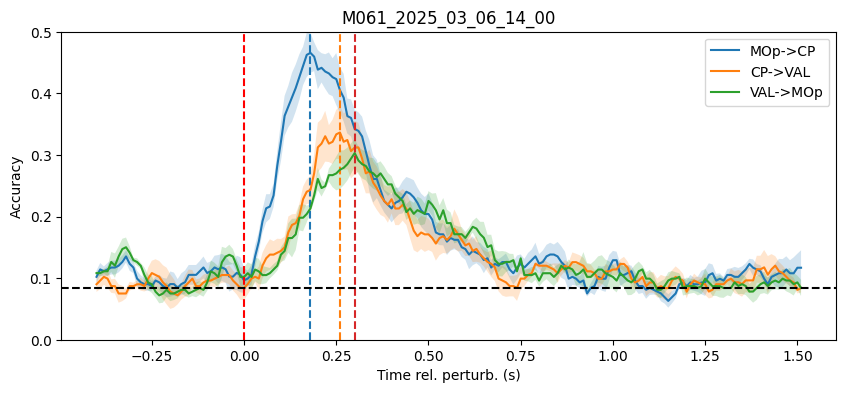

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_mop, errorStat=scipy.stats.sem, label='SSp->MOp')
# ax.axvline(x=times[np.argmax(scores_ssp_mop.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_ssp, errorStat=scipy.stats.sem, label='MOp->SSp')
# ax.axvline(x=times[np.argmax(scores_mop_ssp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_bhv, errorStat=scipy.stats.sem, label='MOp->Bhv')
# ax.axvline(x=times[np.argmax(scores_mop_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv, errorStat=scipy.stats.sem, label='Bhv')
# ax.axvline(x=times[np.argmax(scores_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_ssp, errorStat=scipy.stats.sem, label='Bhv->SSp')
# ax.axvline(x=times[np.argmax(scores_bhv_ssp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')


vizutils.shaded_errorbar(ax, times-0.5, scores_mop_cp, errorStat=scipy.stats.sem, label='MOp->CP')
ax.axvline(x=times[np.argmax(scores_mop_cp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_cp, errorStat=scipy.stats.sem, label='SSp->CP')
# ax.axvline(x=times[np.argmax(scores_ssp_cp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')


# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_val, errorStat=scipy.stats.sem, label='MOp->VAL')
# ax.axvline(x=times[np.argmax(scores_mop_val.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

vizutils.shaded_errorbar(ax, times-0.5, scores_cp_val, errorStat=scipy.stats.sem, label='CP->VAL')
ax.axvline(x=times[np.argmax(scores_cp_val.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop, errorStat=scipy.stats.sem, label='MOp')
# ax.axvline(x=times[np.argmax(scores_mop.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_cp, errorStat=scipy.stats.sem, label='CP')
# ax.axvline(x=times[np.argmax(scores_cp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_val_mop, errorStat=scipy.stats.sem, label='VAL->MOp')
# ax.axvline(x=times[np.argmax(scores_val_mop.mean(axis=-1))]-0.5, color='tab:red', linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}')
plt.show()

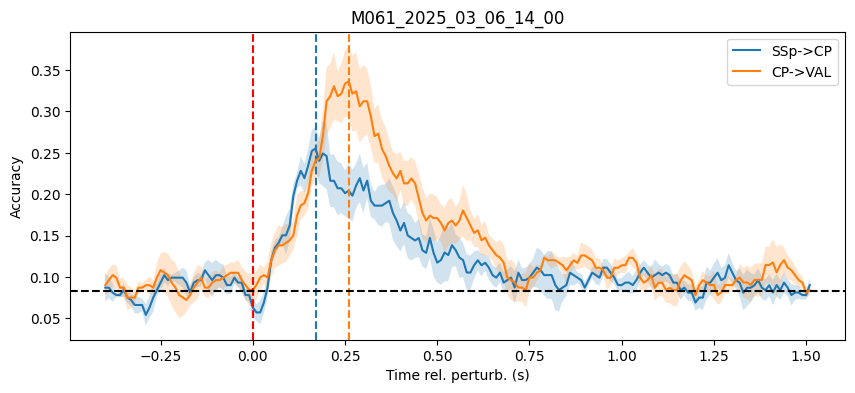

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_mop, errorStat=scipy.stats.sem, label='SSp->MOp')
# ax.axvline(x=times[np.argmax(scores_ssp_mop.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_ssp, errorStat=scipy.stats.sem, label='MOp->SSp')
# ax.axvline(x=times[np.argmax(scores_mop_ssp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_bhv, errorStat=scipy.stats.sem, label='MOp->Bhv')
# ax.axvline(x=times[np.argmax(scores_mop_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv, errorStat=scipy.stats.sem, label='Bhv')
# ax.axvline(x=times[np.argmax(scores_bhv.mean(axis=-1))]-1, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_cp, errorStat=scipy.stats.sem, label='MOp->CP')
# ax.axvline(x=times[np.argmax(scores_mop_cp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_val, errorStat=scipy.stats.sem, label='MOp->VAL')
# ax.axvline(x=times[np.argmax(scores_mop_val.mean(axis=-1))]-0.5, color='tab:green', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_cp, errorStat=scipy.stats.sem, label='SSp->CP')
# ax.axvline(x=times[np.argmax(scores_ssp_cp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_cp_val, errorStat=scipy.stats.sem, label='CP->VAL')
# ax.axvline(x=times[np.argmax(scores_cp_val.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_val_mop, errorStat=scipy.stats.sem, label='VAL->MOp')
# ax.axvline(x=times[np.argmax(scores_val_mop.mean(axis=-1))]-0.5, color='tab:green', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_val, errorStat=scipy.stats.sem, label='VAL->SSp')
# ax.axvline(x=times[np.argmax(scores_ssp_val.mean(axis=-1))]-0.5, color='tab:green', linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.45)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}')
plt.show()

## M063

In [130]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M063_2025_03_14_15_30',
    combine_time_bins=False
)
df_ = handler.df

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
field idx_motion could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
fie

/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

Resulting VAL_spikes ephys data shape is (NxT): (260, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (92, 60000)
Resulting all_spikes ephys data shape is (NxT): (38, 60000)
Resulting CP_spikes ephys data shape is (NxT): (329, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (161, 60000)


In [131]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
# df = dt.add_bhv(df)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -50, rel_end= 150)
targets = df.values_Sol_direction.values.tolist()[:-1]

In [132]:
from_area = 'SSp_rates'
to_area = 'MOp_rates'
bhv = 'bhv'

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), from_area, to_area)
comm_subspace_ssp_mop = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), to_area, from_area)
comm_subspace_mop_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
# comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'bhv')
# comm_subspace_mop_bhv = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'CP_rates')
comm_subspace_mop_cp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'MOp_rates', 'VAL_rates')
comm_subspace_mop_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'CP_rates', 'VAL_rates')
comm_subspace_cp_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'MOp_rates')
comm_subspace_val_mop = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'SSp_rates', 'VAL_rates')
comm_subspace_ssp_val = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'VAL_rates', 'SSp_rates')
comm_subspace_val_ssp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'SSp_rates', 'CP_rates')
comm_subspace_ssp_cp = subspaces.get_output_potent_projector(comm_lr)

# Get subspace projector
# comm_lr = pyal.fit_regressor_model(df, LinearRegression(), 'bhv', 'SSp_rates')
# comm_subspace_bhv_ssp = subspaces.get_output_potent_projector(comm_lr)

In [133]:
projected_ssp_mop = np.array([arr @ comm_subspace_ssp_mop for arr in perturb_td.SSp_rates.values])
projected_mop_ssp = np.array([arr @ comm_subspace_mop_ssp for arr in perturb_td.MOp_rates.values])
# projected_mop_bhv = np.array([arr @ comm_subspace_mop_bhv for arr in perturb_td.MOp_rates.values])
projected_mop_cp = np.array([arr @ comm_subspace_mop_cp for arr in perturb_td.MOp_rates.values])
projected_mop_val = np.array([arr @ comm_subspace_mop_val for arr in perturb_td.MOp_rates.values])
projected_cp_val = np.array([arr @ comm_subspace_cp_val for arr in perturb_td.CP_rates.values])
projected_val_mop = np.array([arr @ comm_subspace_val_mop for arr in perturb_td.VAL_rates.values])
projected_val_ssp = np.array([arr @ comm_subspace_val_ssp for arr in perturb_td.VAL_rates.values])
projected_ssp_val = np.array([arr @ comm_subspace_ssp_val for arr in perturb_td.SSp_rates.values])
projected_ssp_cp = np.array([arr @ comm_subspace_ssp_cp for arr in perturb_td.SSp_rates.values])
# projected_bhv_ssp = np.array([arr @ comm_subspace_bhv_ssp for arr in perturb_td.bhv.values])

# bhv = np.stack(perturb_td.bhv.values)


In [134]:
k=5
scores_ssp_mop, times = decode.moving_window_decoding(
    projected_ssp_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_ssp, times = decode.moving_window_decoding(
    projected_mop_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

# scores_mop_bhv, times = decode.moving_window_decoding(
#     projected_mop_bhv,
#     targets,
#     window_length_bin=10,
#     step_bin=1,
#     k=k
# )

# scores_bhv, times = decode.moving_window_decoding(
#     bhv,
#     targets,
#     window_length_bin=10,
#     step_bin=1,
#     k=k
# )

scores_mop_cp, times = decode.moving_window_decoding(
    projected_mop_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_mop_val, times = decode.moving_window_decoding(
    projected_mop_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_cp_val, times = decode.moving_window_decoding(
    projected_cp_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_mop, times = decode.moving_window_decoding(
    projected_val_mop,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_ssp_val, times = decode.moving_window_decoding(
    projected_ssp_val,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_val_ssp, times = decode.moving_window_decoding(
    projected_val_ssp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

scores_ssp_cp, times = decode.moving_window_decoding(
    projected_ssp_cp,
    targets,
    window_length_bin=10,
    step_bin=1,
    k=k
)

# scores_bhv_ssp, times = decode.moving_window_decoding(
#     projected_bhv_ssp,
#     targets,
#     window_length_bin=10,
#     step_bin=1,
#     k=k
# )

ValueError: Found input variables with inconsistent numbers of samples: [337, 336]

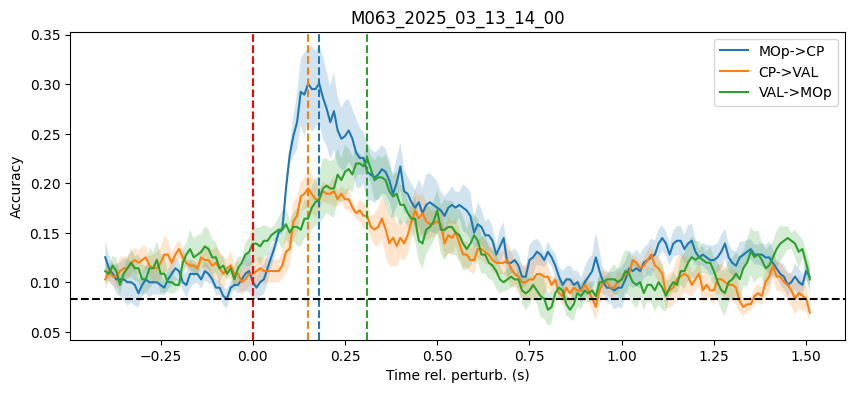

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_mop, errorStat=scipy.stats.sem, label='SSp->MOp')
# ax.axvline(x=times[np.argmax(scores_ssp_mop.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_ssp, errorStat=scipy.stats.sem, label='MOp->SSp')
# ax.axvline(x=times[np.argmax(scores_mop_ssp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_bhv, errorStat=scipy.stats.sem, label='MOp->Bhv')
# ax.axvline(x=times[np.argmax(scores_mop_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv, errorStat=scipy.stats.sem, label='Bhv')
# ax.axvline(x=times[np.argmax(scores_bhv.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_bhv_ssp, errorStat=scipy.stats.sem, label='Bhv->SSp')
# ax.axvline(x=times[np.argmax(scores_bhv_ssp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')


vizutils.shaded_errorbar(ax, times-0.5, scores_mop_cp, errorStat=scipy.stats.sem, label='MOp->CP')
ax.axvline(x=times[np.argmax(scores_mop_cp.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

# vizutils.shaded_errorbar(ax, times-0.5, scores_ssp_cp, errorStat=scipy.stats.sem, label='SSp->CP')
# ax.axvline(x=times[np.argmax(scores_ssp_cp.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')


# vizutils.shaded_errorbar(ax, times-0.5, scores_mop_val, errorStat=scipy.stats.sem, label='MOp->VAL')
# ax.axvline(x=times[np.argmax(scores_mop_val.mean(axis=-1))]-0.5, color='tab:blue', linestyle='dashed')

vizutils.shaded_errorbar(ax, times-0.5, scores_cp_val, errorStat=scipy.stats.sem, label='CP->VAL')
ax.axvline(x=times[np.argmax(scores_cp_val.mean(axis=-1))]-0.5, color='tab:orange', linestyle='dashed')

vizutils.shaded_errorbar(ax, times-0.5, scores_val_mop, errorStat=scipy.stats.sem, label='VAL->MOp')
ax.axvline(x=times[np.argmax(scores_val_mop.mean(axis=-1))]-0.5, color='tab:green', linestyle='dashed')

ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
ax.set_title(f'{handler.session}')
plt.show()